<a href="https://colab.research.google.com/github/AIVIETNAM-AIO-CongNguyen/CV-system-/blob/data-preprocessing/resume_extraction_upgraded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  1. Cài đặt thư viện

In [ ]:
# Cài đặt các thư viện cần thiết
!pip install sentence-transformers transformers torch scikit-learn pandas matplotlib wordcloud nltk
!pip install bert-score rouge-score anthropic tika spacy
!pip install accelerate datasets seaborn
!python -m spacy download en_core_web_sm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 861.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 929.8/929.8 kB 6.0 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=d96f5cb2a25de055434ba358e0f5328a79c61a11a424567386338c55ee88be86
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 34.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 2. Imports

In [ ]:
# ===== CORE =====
import re
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import string
import warnings
warnings.filterwarnings('ignore')

# ===== SKLEARN =====
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# ===== SENTENCE TRANSFORMERS (thay thế TF-IDF) =====
from sentence_transformers import SentenceTransformer, util

# ===== TRANSFORMERS (BERT Fine-tuning) =====
import torch
from torch import nn
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    TrainingArguments, Trainer, AutoTokenizer,
    AutoModel
)
from torch.utils.data import Dataset, DataLoader

# ===== EVALUATION METRICS =====
from bert_score import score as bert_score
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# ===== NLP =====
import spacy
nlp = spacy.load('en_core_web_sm')

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# ===== LLM API =====
import anthropic
import json
import os

print(' All libraries imported successfully!')
print(f' GPU available: {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Using device: {device}')

✅ All libraries imported successfully!
🔥 GPU available: False
📟 Using device: cpu


##  3. Cấu hình

In [ ]:
# ===== CẤU HÌNH TOÀN CỤC =====
PLOT_PALETTE = 'tableau-colorblind10'
WORDCLOUD_COLOR_MAP = 'tab10_r'
plt.style.use(PLOT_PALETTE)
%matplotlib inline

# Model configs
SBERT_MODEL = 'all-MiniLM-L6-v2'          # Nhẹ, nhanh, tốt cho semantic similarity
BERT_MODEL  = 'bert-base-uncased'           # Cho classification
MAX_LENGTH  = 512
BATCH_SIZE  = 16
NUM_EPOCHS  = 3
LEARNING_RATE = 2e-5
RANDOM_STATE  = 42

# API Key (thay bằng key thực của bạn)
ANTHROPIC_API_KEY = os.environ.get('ANTHROPIC_API_KEY', 'your-api-key-here')

print(' Configuration loaded!')

✅ Configuration loaded!


##  4. Preprocessing (Nâng cấp)

In [ ]:
nltk.download('punkt_tab', quiet=True)

def preprocess_basic(txt):
    """Preprocessing cơ bản (giống bản cũ) - dùng cho TF-IDF / word freq."""
    txt = txt.lower()
    txt = re.sub(r'http\S+\s*', ' ', txt)
    txt = re.sub(r'[^a-zA-Z]', ' ', txt)
    txt = re.sub(r'\s+', ' ', txt).strip()
    tokens = nltk.word_tokenize(txt)
    stopwords = set(nltk.corpus.stopwords.words('english'))
    tokens = [w for w in tokens if w not in stopwords and len(w) > 2]
    return ' '.join(tokens)


def preprocess_for_bert(txt, max_words=400):
    """
    Preprocessing nhẹ cho BERT/Sentence-Transformer.
    BERT đã tự tokenize nên KHÔNG nên xóa stopwords.
    Chỉ clean URL, ký tự lạ và cắt bớt độ dài.
    """
    txt = re.sub(r'http\S+\s*', ' ', txt)   # remove URLs
    txt = re.sub(r'[^a-zA-Z0-9\s.,!?-]', ' ', txt)
    txt = re.sub(r'\s+', ' ', txt).strip()
    # Giữ tối đa max_words để tránh quá dài
    words = txt.split()[:max_words]
    return ' '.join(words)


print(' Preprocessing functions defined!')
print('\n So sánh hai cách preprocessing:')
sample = "Experienced Python developer with 5+ years at Google LLC. Visit: https://linkedin.com/in/abc"
print(f'  Basic:    {preprocess_basic(sample)}')
print(f'  For BERT: {preprocess_for_bert(sample)}')

✅ Preprocessing functions defined!

📌 So sánh hai cách preprocessing:
  Basic:    experienced python developer years google llc visit
  For BERT: Experienced Python developer with 5 years at Google LLC. Visit


##  5. Load Data

In [ ]:
# Load dataset (Kaggle: UpdatedResumeDataSet.csv hoặc Resume.csv)
# Thay đổi đường dẫn phù hợp với môi trường của bạn
try:
    df = pd.read_csv('../input/CvsDatasets/ResumeDataSet.csv')
except FileNotFoundError:
    # Demo với dữ liệu giả nếu không có file
    print('  Dataset not found. Creating demo data...')
    demo_data = {
        'Category': ['Data Science', 'Web Designing', 'Java Developer',
                     'Data Science', 'Web Designing', 'Java Developer'] * 10,
        'Resume': [
            'Machine learning engineer with Python TensorFlow experience in deep learning neural networks',
            'Frontend developer skilled in HTML CSS JavaScript React Vue.js responsive design',
            'Java Spring Boot microservices RESTful API backend developer enterprise applications',
            'Data scientist NLP computer vision scikit-learn pandas statistical analysis',
            'UI UX designer Adobe XD Figma prototyping wireframing user interface',
            'Java developer Hibernate Maven SQL database backend systems integration'
        ] * 10
    }
    df = pd.DataFrame(demo_data)

print(f' Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Categories: {df["Category"].nunique()} unique classes')
print(f'\n{df["Category"].value_counts()}')

⚠️  Dataset not found. Creating demo data...
📊 Dataset loaded: 60 rows, 2 columns
📁 Categories: 3 unique classes

Category
Data Science      20
Web Designing     20
Java Developer    20
Name: count, dtype: int64


In [ ]:
# Tạo 2 phiên bản text cho các mục đích khác nhau
print(' Preprocessing resumes...')
df['Resume_clean']     = df['Resume'].apply(preprocess_basic)      # cho EDA
df['Resume_for_bert']  = df['Resume'].apply(preprocess_for_bert)   # cho BERT/SBERT

# Label encoding
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Category'])
num_classes = len(le.classes_)

print(f' Preprocessing done! {num_classes} classes encoded.')
df.head(3)

🔄 Preprocessing resumes...
✅ Preprocessing done! 3 classes encoded.


,Category,Resume,Resume_clean,Resume_for_bert,Label
0,Data Science,Machine learning engineer with Python TensorFl...,machine learning engineer python tensorflow ex...,Machine learning engineer with Python TensorFl...,0
1,Web Designing,Frontend developer skilled in HTML CSS JavaScr...,frontend developer skilled html css javascript...,Frontend developer skilled in HTML CSS JavaScr...,2
2,Java Developer,Java Spring Boot microservices RESTful API bac...,java spring boot microservices restful api bac...,Java Spring Boot microservices RESTful API bac...,1


##  6. Exploratory Data Analysis (EDA)

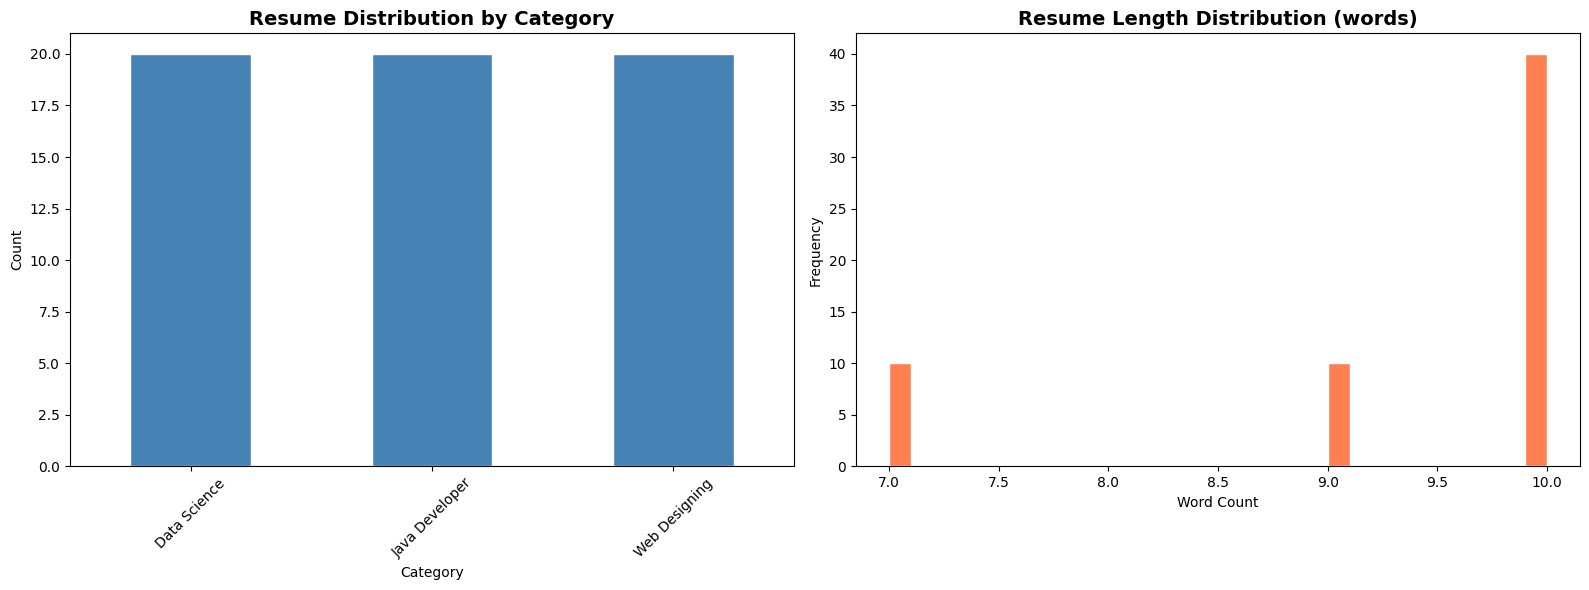


📏 Average resume length: 9 words


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
counts = df['Category'].value_counts().sort_index()
counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Resume Distribution by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Resume length distribution
df['Resume_length'] = df['Resume_clean'].apply(lambda x: len(x.split()))
df['Resume_length'].plot(kind='hist', ax=axes[1], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Resume Length Distribution (words)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print(f'\n📏 Average resume length: {df["Resume_length"].mean():.0f} words')

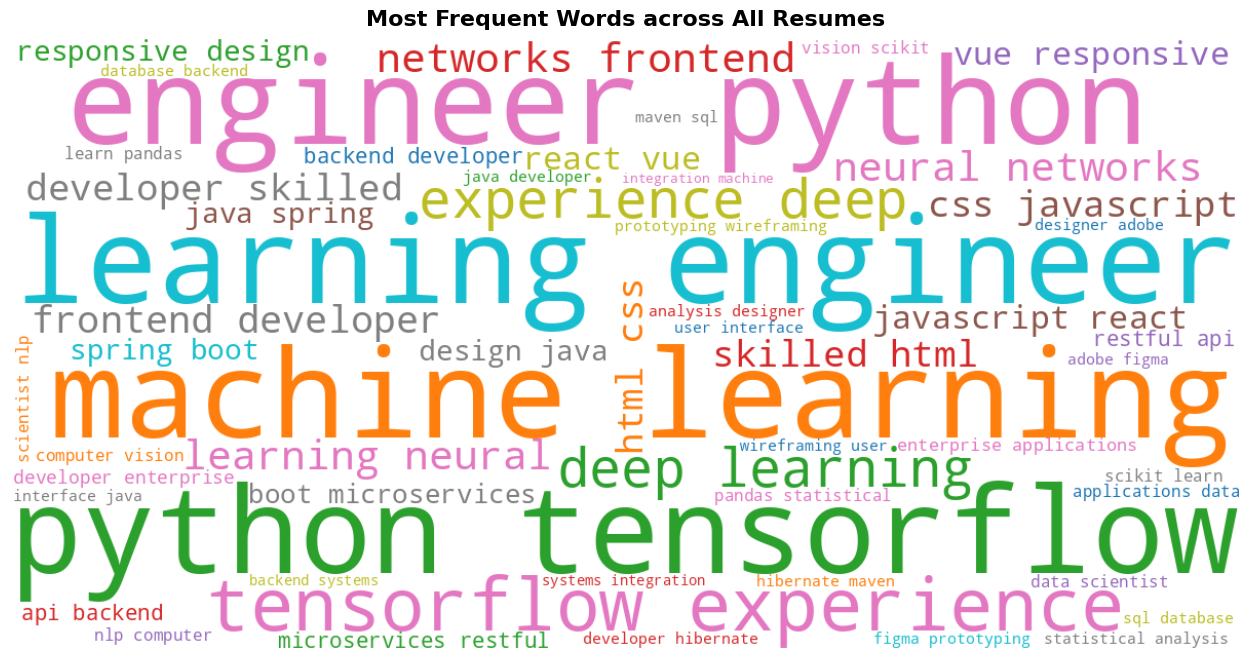

In [ ]:
# Word Cloud tổng hợp
all_text = ' '.join(df['Resume_clean'])
wc = WordCloud(width=1200, height=600, colormap=WORDCLOUD_COLOR_MAP,
               background_color='white', max_words=200).generate(all_text)
plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words across All Resumes', fontsize=16, fontweight='bold')
plt.show()